In [121]:
# pip install wordcloud

In [122]:
# pip install tensorflow --upgrade

In [123]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud
from collections import Counter
import re
import string

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from tensorflow import keras

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Embedding, Flatten, Conv1D, GlobalMaxPooling1D

from tensorflow.keras.callbacks import EarlyStopping

import tensorflow as tf

EDA PROCESS

In [124]:
df = pd.read_csv('spam_ham_dataset.csv')
df.head()

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


In [125]:
print("Shape of dataset:",df.shape)
print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

df.drop(columns=['Unnamed: 0'], inplace=True)
df.head()

Shape of dataset: (5171, 4)

Data Types:
Unnamed: 0     int64
label         object
text          object
label_num      int64
dtype: object

Missing Values:
Unnamed: 0    0
label         0
text          0
label_num     0
dtype: int64

Duplicate Rows: 0


,label,text,label_num
0,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,spam,"Subject: photoshop , windows , office . cheap ...",1
4,ham,Subject: re : indian springs\r\nthis deal is t...,0


label
ham     3672
spam    1499
Name: count, dtype: int64


C:\Users\greg3\AppData\Local\Temp\ipykernel_38924\3929767055.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', palette='viridis')


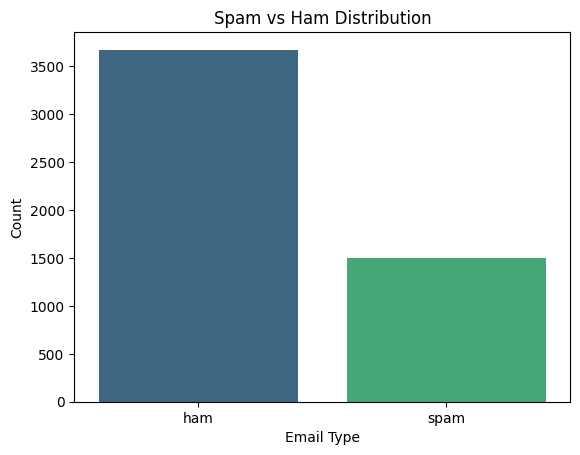

In [126]:
print(df['label'].value_counts())

# Plot distribution
sns.countplot(data=df, x='label', palette='viridis')
plt.title("Spam vs Ham Distribution")
plt.xlabel("Email Type")
plt.ylabel("Count")
plt.show()

In [127]:
# Character count
df['char_count'] = df['text'].apply(len)

# Word count
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

# Sentence count
df['sentence_count'] = df['text'].apply(lambda x: len(re.findall(r'[.!?]+', str(x))))

df[['char_count', 'word_count', 'sentence_count']].head()

,char_count,word_count,sentence_count
0,327,67,3
1,97,23,2
2,2524,550,23
3,414,48,2
4,336,70,3


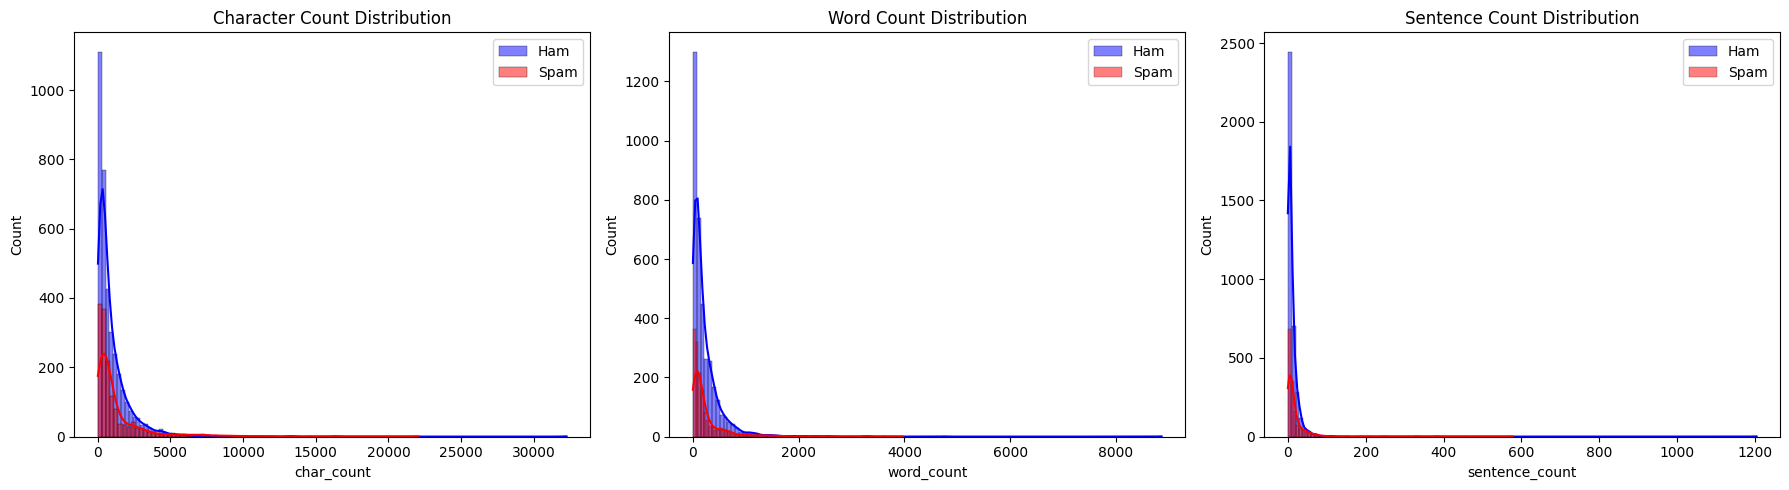

In [128]:
fig, axes = plt.subplots(1,3, figsize=(18,5))

sns.histplot(df[df['label']=='ham']['char_count'],
             color='blue', label='Ham',
             kde=True, ax=axes[0])

sns.histplot(df[df['label']=='spam']['char_count'],
             color='red', label='Spam',
             kde=True, ax=axes[0])

axes[0].set_title("Character Count Distribution")
axes[0].legend()


sns.histplot(df[df['label']=='ham']['word_count'],
             color='blue', label='Ham',
             kde=True, ax=axes[1])

sns.histplot(df[df['label']=='spam']['word_count'],
             color='red', label='Spam',
             kde=True, ax=axes[1])

axes[1].set_title("Word Count Distribution")
axes[1].legend()


sns.histplot(df[df['label']=='ham']['sentence_count'],
             color='blue', label='Ham',
             kde=True, ax=axes[2])

sns.histplot(df[df['label']=='spam']['sentence_count'],
             color='red', label='Spam',
             kde=True, ax=axes[2])

axes[2].set_title("Sentence Count Distribution")
axes[2].legend()

plt.tight_layout()
plt.show()

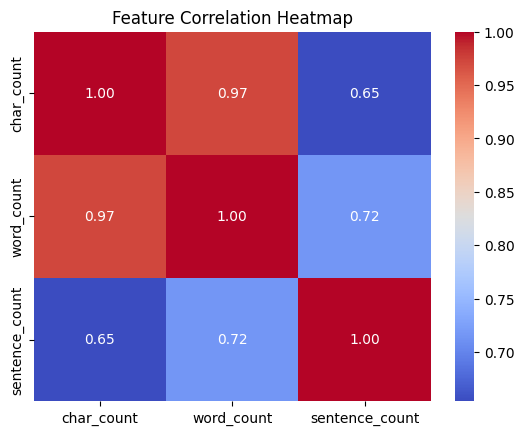

In [129]:
corr = df[['char_count',
           'word_count',
           'sentence_count']].corr()

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title("Feature Correlation Heatmap")
plt.show()

In [130]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"\d+", "", text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = text.strip()
    return text

df['clean_text'] = df['text'].apply(clean_text)

df[['text', 'clean_text']].head()

,text,clean_text
0,Subject: enron methanol ; meter # : 988291\r\n...,subject enron methanol meter \r\nthis is a ...
1,"Subject: hpl nom for january 9 , 2001\r\n( see...",subject hpl nom for january \r\n see attache...
2,"Subject: neon retreat\r\nho ho ho , we ' re ar...",subject neon retreat\r\nho ho ho we re aroun...
3,"Subject: photoshop , windows , office . cheap ...",subject photoshop windows office cheap mai...
4,Subject: re : indian springs\r\nthis deal is t...,subject re indian springs\r\nthis deal is to ...


C:\Users\greg3\AppData\Local\Temp\ipykernel_38924\3015331823.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=spam_df, x='Count', y='Word', palette='Reds_r')


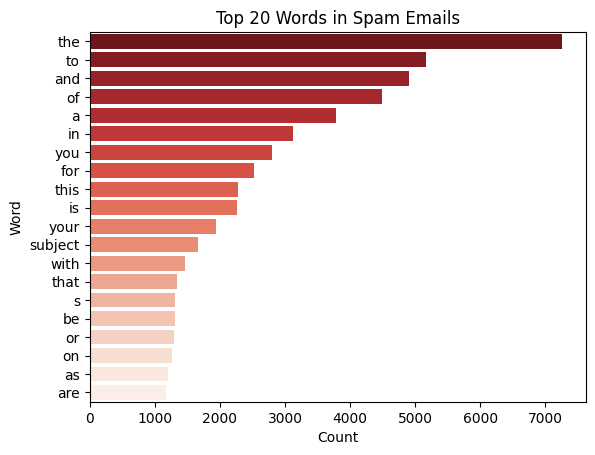

In [131]:
def get_top_words(text_series, n=20):
    words = ' '.join(text_series).split()
    counter = Counter(words)
    return counter.most_common(n)

# Top words in spam
spam_words = get_top_words(df[df['label']=='spam']['clean_text'])

spam_df = pd.DataFrame(spam_words, columns=['Word', 'Count'])

sns.barplot(data=spam_df, x='Count', y='Word', palette='Reds_r')
plt.title("Top 20 Words in Spam Emails")
plt.show()

C:\Users\greg3\AppData\Local\Temp\ipykernel_38924\2169442683.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ham_df, x='Count', y='Word', palette='Blues_r')


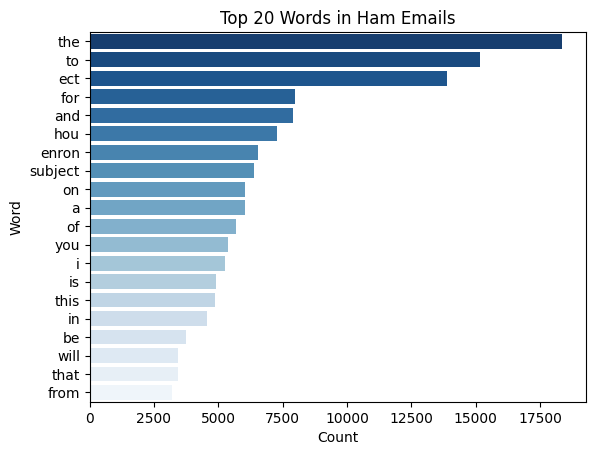

In [132]:
ham_words = get_top_words(df[df['label']=='ham']['clean_text'])

ham_df = pd.DataFrame(ham_words, columns=['Word', 'Count'])

sns.barplot(data=ham_df, x='Count', y='Word', palette='Blues_r')
plt.title("Top 20 Words in Ham Emails")
plt.show()

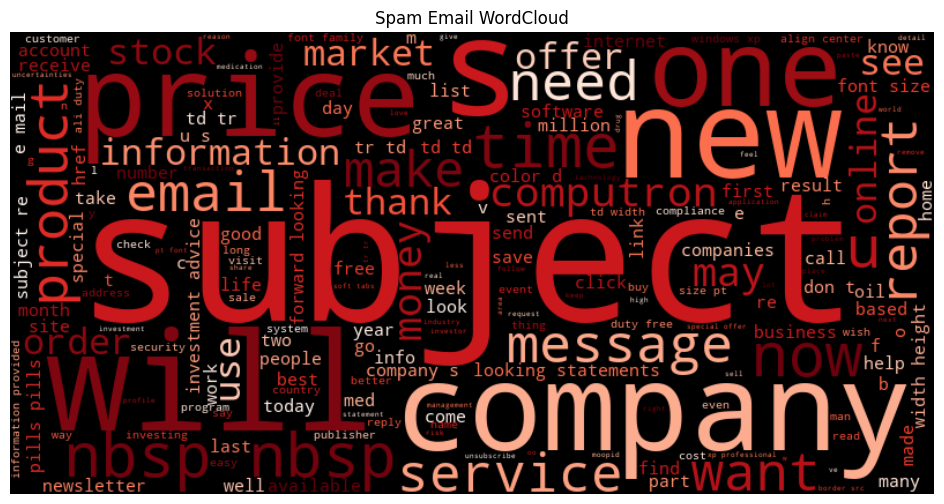

In [133]:
spam_text = ' '.join(df[df['label']=='spam']['clean_text'])

spam_wc = WordCloud(width=800,
                    height=400,
                    background_color='black',
                    colormap='Reds').generate(spam_text)

plt.figure(figsize=(12,6))
plt.imshow(spam_wc, interpolation='bilinear')
plt.axis('off')
plt.title("Spam Email WordCloud")
plt.show()

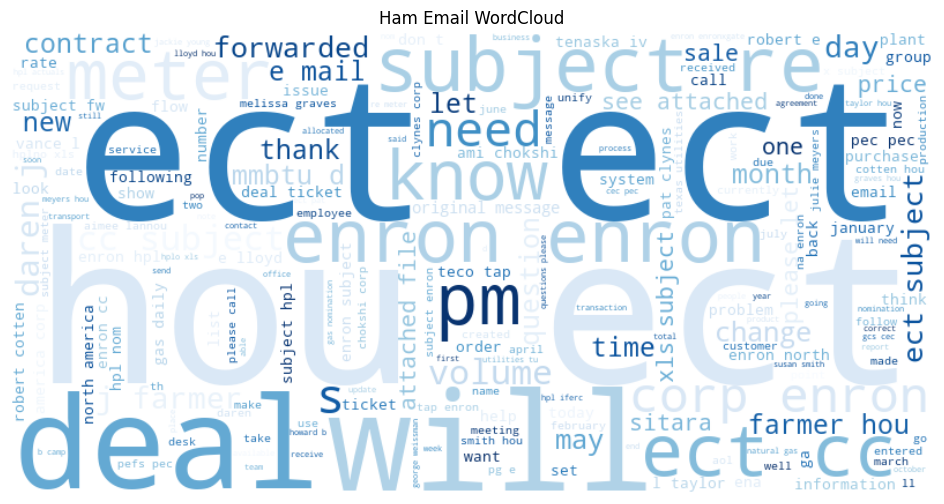

In [134]:
ham_text = ' '.join(df[df['label']=='ham']['clean_text'])

ham_wc = WordCloud(width=800,
                   height=400,
                   background_color='white',
                   colormap='Blues').generate(ham_text)

plt.figure(figsize=(12,6))
plt.imshow(ham_wc, interpolation='bilinear')
plt.axis('off')
plt.title("Ham Email WordCloud")
plt.show()

C:\Users\greg3\AppData\Local\Temp\ipykernel_38924\3789344382.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='char_count', palette='Set2', ax=axes[0])
C:\Users\greg3\AppData\Local\Temp\ipykernel_38924\3789344382.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='word_count', palette='Set2', ax=axes[1])


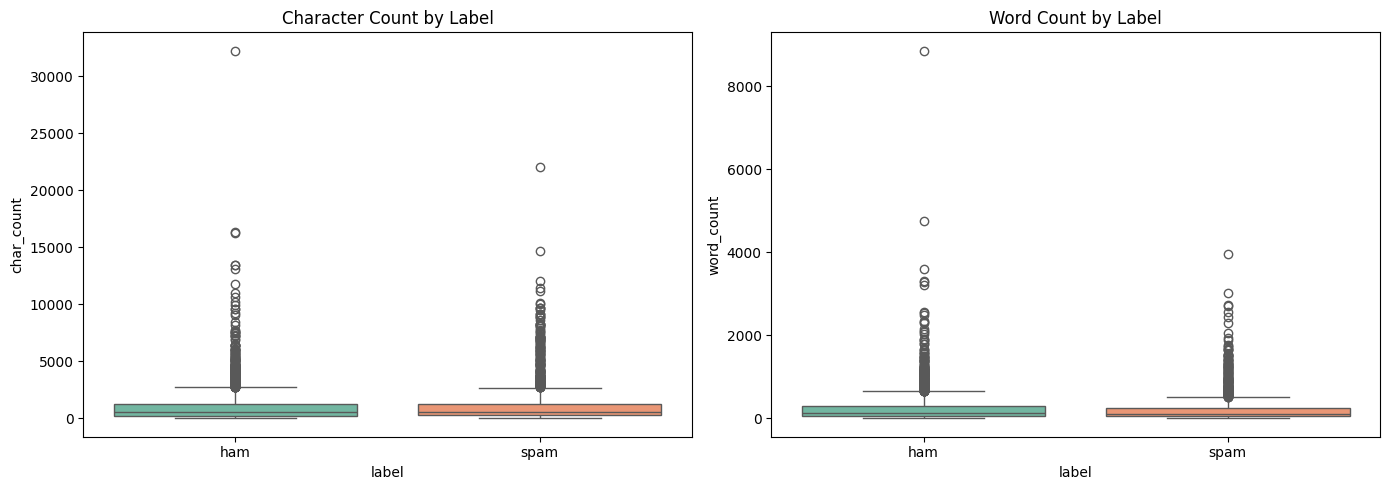

In [135]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

sns.boxplot(data=df, x='label', y='char_count', palette='Set2', ax=axes[0])
axes[0].set_title("Character Count by Label")

sns.boxplot(data=df, x='label', y='word_count', palette='Set2', ax=axes[1])
axes[1].set_title("Word Count by Label")

plt.tight_layout()
plt.show()

MLP

In [136]:
encoder = LabelEncoder()

df['label'] = encoder.fit_transform(df['label'])

# ham = 0
# spam = 1

In [137]:
X = df['clean_text']

# Labels
y = df['label']

# Encode labels
encoder = LabelEncoder()
y = encoder.fit_transform(y)

print("Classes:", encoder.classes_)

Classes: [0 1]


In [138]:
X_train, X_test, y_train, y_test = train_test_split(
    df['text'],
    df['label'],
    test_size=0.2,
    stratify=df['label'],
    random_state=42
)

In [139]:
max_words = 5000
max_len = 100

tokenizer = Tokenizer(num_words=max_words)

tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

In [140]:
classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = dict(enumerate(weights))

print(class_weights)

{0: np.float64(0.704119850187266), 1: np.float64(1.724770642201835)}


In [141]:
mlp_model = Sequential([

    Embedding(
        input_dim=max_words,
        output_dim=64,
        input_length=max_len
    ),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

mlp_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

mlp_model.summary()

c:\Users\greg3\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [142]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_mlp = mlp_model.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7981 - loss: 0.4031 - val_accuracy: 0.9432 - val_loss: 0.1396
Epoch 2/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9846 - loss: 0.0456 - val_accuracy: 0.9541 - val_loss: 0.1273
Epoch 3/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9967 - loss: 0.0121 - val_accuracy: 0.9638 - val_loss: 0.1091
Epoch 4/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9988 - loss: 0.0050 - val_accuracy: 0.9577 - val_loss: 0.1739
Epoch 5/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9979 - loss: 0.0056 - val_accuracy: 0.9589 - val_loss: 0.1423
Epoch 6/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9994 - loss: 0.0028 - val_accuracy: 0.9553 - val_loss: 0.1610


In [155]:
mlp_loss, mlp_acc = mlp_model.evaluate(X_test_pad, y_test)

mlp_pred = (mlp_model.predict(X_test_pad) > 0.5).astype(int)

print("MLP REPORT")
print("MLP Accuracy:", mlp_acc)
print(classification_report(y_test, mlp_pred))

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9720 - loss: 0.0828
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
MLP REPORT
MLP Accuracy: 0.9719806909561157
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       735
           1       0.93      0.98      0.95       300

    accuracy                           0.97      1035
   macro avg       0.96      0.97      0.97      1035
weighted avg       0.97      0.97      0.97      1035



CNN

In [144]:
cnn_model = Sequential([

    Embedding(
        input_dim=max_words,
        output_dim=64,
        input_length=max_len
    ),

    Conv1D(
        filters=128,
        kernel_size=5,
        activation='relu'
    ),

    GlobalMaxPooling1D(),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [145]:
history_cnn = cnn_model.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8467 - loss: 0.4223 - val_accuracy: 0.9432 - val_loss: 0.1446
Epoch 2/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9731 - loss: 0.0723 - val_accuracy: 0.9589 - val_loss: 0.1151
Epoch 3/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9946 - loss: 0.0191 - val_accuracy: 0.9601 - val_loss: 0.1192


In [154]:
cnn_loss, cnn_acc = cnn_model.evaluate(X_test_pad, y_test)


cnn_pred = (cnn_model.predict(X_test_pad) > 0.5).astype(int)

print("CNN REPORT")
print("CNN Accuracy:", cnn_acc)
print(classification_report(y_test, cnn_pred))

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9517 - loss: 0.1260
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
CNN REPORT
CNN Accuracy: 0.9516907930374146
              precision    recall  f1-score   support

           0       0.99      0.94      0.97       735
           1       0.87      0.98      0.92       300

    accuracy                           0.95      1035
   macro avg       0.93      0.96      0.94      1035
weighted avg       0.96      0.95      0.95      1035



REPORTS

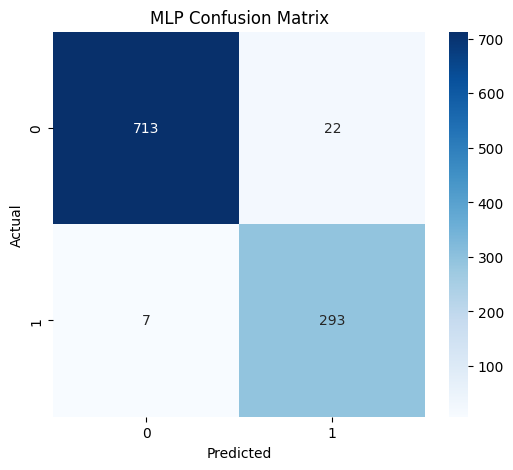

In [148]:
cm = confusion_matrix(y_test, mlp_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("MLP Confusion Matrix")

plt.show()

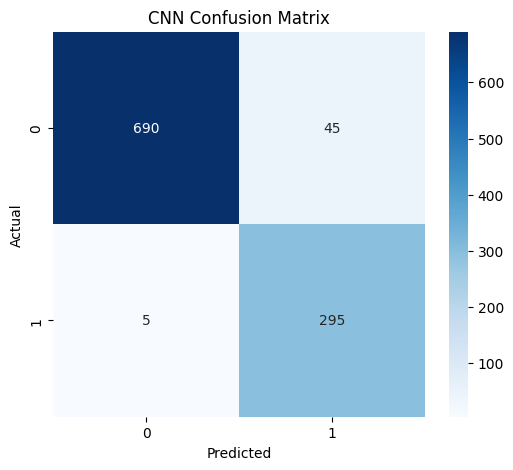

In [149]:
cm = confusion_matrix(y_test, cnn_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN Confusion Matrix")

plt.show()